# Simple RNN and LSTM in Google Colab

This notebook compares a SimpleRNN and an LSTM on the classic Air Passengers forecasting problem.

In [ ]:
%pip install -q tensorflow scikit-learn matplotlib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

keras.utils.set_random_seed(42)

print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU devices: []


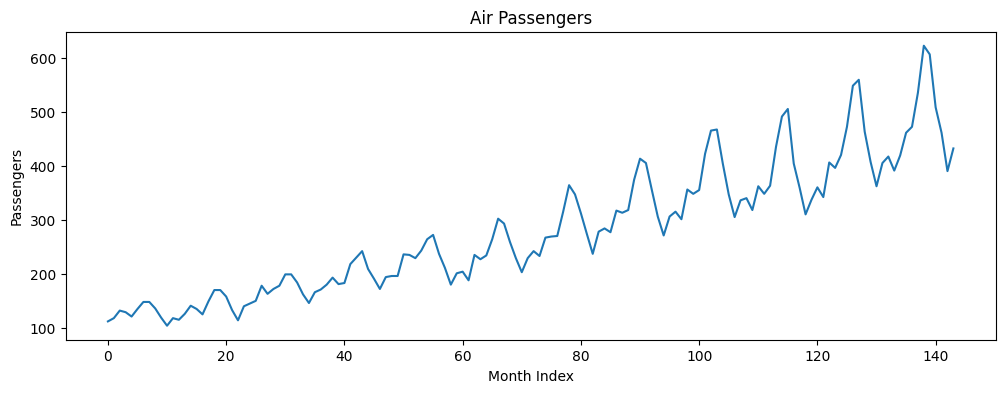

In [ ]:
air_passengers = np.array([
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432,
], dtype='float32')

plt.figure(figsize=(12, 4))
plt.plot(air_passengers)
plt.title('Air Passengers')
plt.xlabel('Month Index')
plt.ylabel('Passengers')
plt.show()


In [ ]:
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(air_passengers.reshape(-1, 1)).astype('float32')

look_back = 12
train_size = int(len(series_scaled) * 0.8)
train_series = series_scaled[:train_size]
test_series = series_scaled[train_size - look_back:]

train_dataset = keras.utils.timeseries_dataset_from_array(
    data=train_series[:-look_back],
    targets=train_series[look_back:],
    sequence_length=look_back,
    batch_size=16,
    shuffle=False,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    data=test_series[:-look_back],
    targets=test_series[look_back:],
    sequence_length=look_back,
    batch_size=16,
    shuffle=False,
)

train_dataset

<_BatchDataset element_spec=(TensorSpec(shape=(None, None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

In [ ]:
simple_rnn_model = keras.Sequential([
    keras.Input(shape=(look_back, 1)),
    layers.SimpleRNN(32, activation='tanh'),
    layers.Dropout(0.2),
    layers.Dense(1),
])

simple_rnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae'],
)

lstm_model = keras.Sequential([
    keras.Input(shape=(look_back, 1)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss='mse',
    metrics=['mae'],
)

simple_rnn_model.summary()
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
    ),
]

history_rnn = simple_rnn_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=60,
    callbacks=callbacks,
    verbose=0,
)

history_lstm = lstm_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=60,
    callbacks=callbacks,
    verbose=0,
)


## 7. What To Do After Training

For sequence models, the demo should answer:

- how close predictions are to the real sequence
- whether the model captures the trend
- whether the LSTM improves on the simpler RNN


In [ ]:
y_true_scaled = np.concatenate([y for _, y in test_dataset], axis=0).reshape(-1, 1)
y_true = scaler.inverse_transform(y_true_scaled).ravel()

rnn_pred_scaled = simple_rnn_model.predict(test_dataset, verbose=0).reshape(-1, 1)
lstm_pred_scaled = lstm_model.predict(test_dataset, verbose=0).reshape(-1, 1)

rnn_pred = scaler.inverse_transform(rnn_pred_scaled).ravel()
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).ravel()

print('SimpleRNN RMSE:', round(np.sqrt(mean_squared_error(y_true, rnn_pred)), 2))
print('SimpleRNN MAE :', round(mean_absolute_error(y_true, rnn_pred), 2))
print('LSTM RMSE     :', round(np.sqrt(mean_squared_error(y_true, lstm_pred)), 2))
print('LSTM MAE      :', round(mean_absolute_error(y_true, lstm_pred), 2))


SimpleRNN RMSE: 27.57
SimpleRNN MAE : 23.8
LSTM RMSE     : 199.11
LSTM MAE      : 186.66


In [ ]:
for i in range(min(8, len(y_true))):
    print(f'Step {i:02d} | actual={y_true[i]:7.2f} | rnn={rnn_pred[i]:7.2f} | lstm={lstm_pred[i]:7.2f}')


Step 00 | actual= 505.00 | rnn= 493.17 | lstm= 219.38
Step 01 | actual= 404.00 | rnn= 449.88 | lstm= 221.22
Step 02 | actual= 359.00 | rnn= 378.04 | lstm= 223.57
Step 03 | actual= 310.00 | rnn= 335.39 | lstm= 225.78
Step 04 | actual= 337.00 | rnn= 382.34 | lstm= 227.05
Step 05 | actual= 360.00 | rnn= 357.10 | lstm= 226.99
Step 06 | actual= 342.00 | rnn= 361.09 | lstm= 226.63
Step 07 | actual= 406.00 | rnn= 386.83 | lstm= 226.21


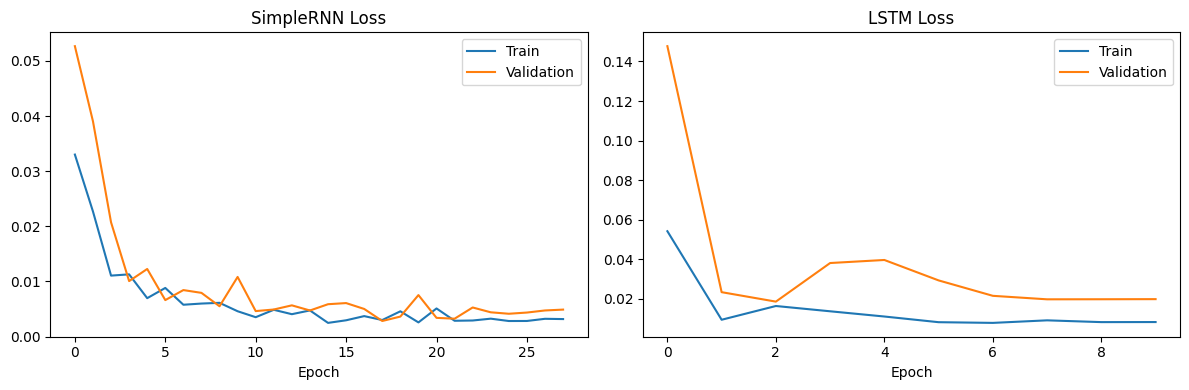

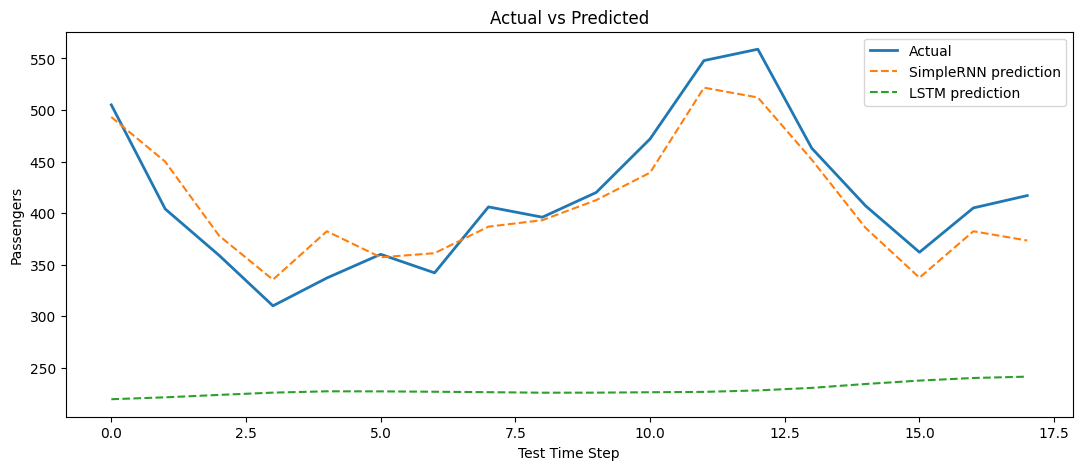

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_rnn.history['loss'], label='Train')
axes[0].plot(history_rnn.history['val_loss'], label='Validation')
axes[0].set_title('SimpleRNN Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_lstm.history['loss'], label='Train')
axes[1].plot(history_lstm.history['val_loss'], label='Validation')
axes[1].set_title('LSTM Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 5))
plt.plot(y_true, label='Actual', linewidth=2)
plt.plot(rnn_pred, label='SimpleRNN prediction', linestyle='--')
plt.plot(lstm_pred, label='LSTM prediction', linestyle='--')
plt.title('Actual vs Predicted')
plt.xlabel('Test Time Step')
plt.ylabel('Passengers')
plt.legend()
plt.show()


## 8. Summary:

- RNN-style models are designed for ordered data.
- The most important result is not just the loss value, but how the predicted sequence compares with the real one.
- Visual comparison helps students understand forecasting quality immediately.
- LSTM is introduced as the stronger memory-based version of a simple RNN.


In [ ]:
simple_rnn_model.save('simple_rnn_air_passengers.keras')
lstm_model.save('lstm_air_passengers.keras')
print('Saved models to simple_rnn_air_passengers.keras and lstm_air_passengers.keras')


Saved models to simple_rnn_air_passengers.keras and lstm_air_passengers.keras
